# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
!pip install -q scikit-learn pandas joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

In [11]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78424 entries, 0 to 78423
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sensor_id    78424 non-null  int64  
 1   lat          78424 non-null  float64
 2   lon          78424 non-null  float64
 3   pressure     78424 non-null  float64
 4   temperature  78424 non-null  float64
 5   humidity     78424 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 3.6 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [9]:
# Check for missing values
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)
print(f"Rows removed: {rows_before - rows_after}")


# Display summary statistics
display(df_clean.describe())


Rows removed: 0


,sensor_id,lat,lon,pressure,temperature,humidity
count,78424.000000,78424.000000,78424.000000,78424.000000,78424.000000,78424.000000
mean,2692.641959,42.680571,23.335544,94693.534957,25.905160,51.345216
std,676.131437,0.025757,0.040268,617.088735,7.749852,24.301342
min,1764.000000,42.622000,23.254000,92061.020000,13.630000,0.000000
25%,2216.000000,42.665000,23.310000,94404.995000,19.090000,32.060000
50%,2294.000000,42.685000,23.333000,94754.585000,24.730000,50.500000
75%,3436.000000,42.694000,23.360000,95053.167500,31.300000,72.840000
max,3968.000000,42.738000,23.419000,95966.340000,60.470000,100.000000


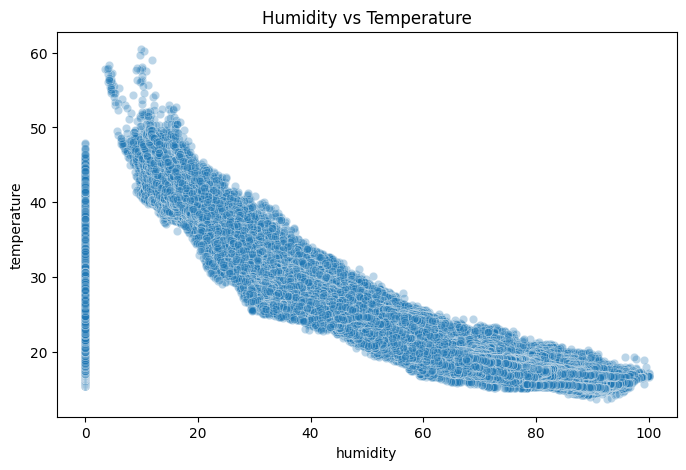

In [12]:
# Scatter plot to observe relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x='humidity', y='temperature', data=df, alpha=0.3)
plt.title('Humidity vs Temperature')
plt.show()

## Data Preprocessing

In [13]:
# Drop any rows with missing values
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning : {rows_after}")
print(f"Rows removed        : {rows_before - rows_after}")


# Define features(X) and target(Y)
X = df_clean.drop('temperature', axis=1)
y = df_clean['temperature']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')


Rows before cleaning: 78424
Rows after cleaning : 78424
Rows removed        : 0
Train size: 62739, Test size: 15685


## Model Training

In [14]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


## Evaluation


In [16]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 12.584718780776015
R-squared: 0.7911139043399569


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


In [17]:
# Save the trained model
joblib.dump(model, "temperature_model.pkl")
print("Model saved to temperature_model.pkl")

Model saved to temperature_model.pkl
